# Lab 9: Preprocessing obrazów na potrzeby ML

Podczas dzisiejszych zajęć wykorzystamy popularne narzędzia (`scikit-image`, `numpy`, `scikit-learn`) do demonstracji podstawowych i zaawansowanych technik przekształcania zdjęć przed wpuszczeniem ich do modeli sztucznej inteligencji.

Inne, bardzo popularne biblioteki dostępne z poziomu języka Python to OpenCV oraz Pillow.

Zaczynamy od załadowania odpowiednich bibliotek:

In [ ]:
!pip install scikit-image[data]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, color, util
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

import warnings
warnings.filterwarnings('ignore')

## 1. Zmiana rozmiaru i kadrowanie

Modele Machine Learning oczekują, by każdy przykład uczący miał dokładnie taką samą strukturę (rozmiar). Należy przycinać lub skalować obrazy zachowując możliwie jak najwięcej oryginalnych proporcji.

Oryginalny rozmiar: (512, 512, 3)


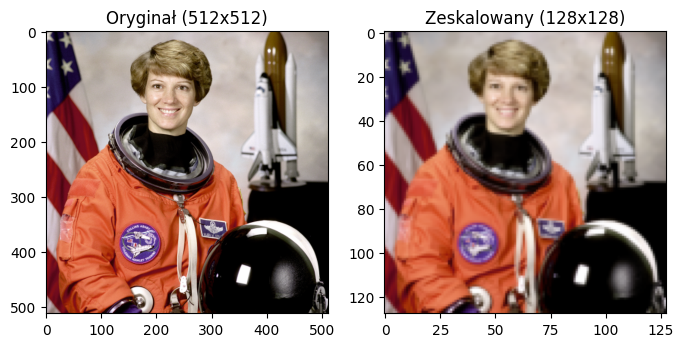

In [12]:
image_raw = data.astronaut() # Przykładowy wbudowany obraz w module scikit-image
print(f"Oryginalny rozmiar: {image_raw.shape}")

# Przykład zmiany rozmiaru do 128x128 bez dbania o proporcje
image_resized_example = transform.resize(image_raw, (128, 128))

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(image_raw)
ax[0].set_title("Oryginał (512x512)")
ax[1].imshow(image_resized_example)
ax[1].set_title("Zeskalowany (128x128)")
plt.show()

### ZADANIE 1:
Załaduj zdjęcie kota z bazy `data.chelsea()`.

Zamiast drastycznie ściskać zdjęcie, najpierw utnij brzegi (wykonaj center crop) tak by zdjęcie stało się kwadratem, a DOPIERO POTEM przeskaluj je do wymiarów 128x128.
Wyświetl na wykresie oryginał oraz wynik prac.
```python
# import zdjęcia wykonasz poprzez uruchomienie
cat_image = data.chelsea()
```

## 2. Skala szarości i spłaszczanie
Klasyczne modele (jak Drzewa Decyzyjne czy SVM) potrzebują macierzy jednowymiarowej dla pojedynczej próbki.

### ZADANIE 2:

Weź zdjęcie astronauty (`image_resized_example` wyżej). 
1. Przekonwertuj je do skali szarości używając `color.rgb2gray`.
2. Spłaszcz (metoda .flatten() lub .reshape(-1)) tak, by powstał jeden wektor z pikselami.
3. Wypisz za pomocą print() jego kształt (powinno wynosić 128 * 128 = 16384 cech).

## 3. Skalowanie i standaryzacja

Biblioteka `scikit-image` podczas użycia modułu `transform` czy `color` bardzo często automatycznie zamienia wartości (0-255) z typu uint8 na typ zmiennoprzecinkowy `float` o zakresie od `0.0` do `1.0`. Taka min-max normalizacja ułatwia pracę modelom.
Czasem wymagana jest głębsza standaryzacja - tzw. algorytm **Z-Score**.

### ZADANIE 3:

Użyj `StandardScaler` ze scikit-learn. 
1. Zaaplikuj go do uzyskanego w Zadaniu 2 spłaszczonego, szarego wektora.

**UWAGA:** StandardScaler przyjmuje dane 2D (wiersze=próbki, kolumny=cechy), 
więc musisz zmienić kształt wektora na reshape(1, -1) zanim wykonasz .fit_transform().

2. Wypisz z użyciem metody `.mean()` i `.std()` średnią i odchylenie standardowe NOWEGO, 
przeskalowanego wektora.

## 4. Podstawowa augmentacja danych

Aby sieć neuronowa nauczyła się, że „pies to pies, nawet jak patrzy w lewo”, używamy technik augmentacji, dynamicznie modyfikując obrazy w czasie treningu.

### ZADANIE 4:
Posługując się podstawowym, kolorowym obrazem `data.astronaut()` wykonaj:
1. Lustrzane odbicie poziome (użyj slice'owania np. `img[:, ::-1, :]` albo funkcji bibliotecznych z np. `np.fliplr`).
2. Dodaj szum za pomocą funkcji `util.random_noise()` do oryginalnego zdjęcia.
3. Wyświetl oryginalny obraz oraz oba zmodyfikowane w jednym rzędzie na 3 wykresach.

## 5. Redukcja wymiarowości - PCA

PCA jest świetnym narzędziem nie tylko do wydobywania unikalnych cech z klasycznych datasetów, ale też do mocnej kompresji obrazów.

Na potrzeby tego punktu wykorzystamy zbiór wbudowany w `sklearn`, mianowicie `digits` – jest to zbiór ponad tysiąca małych obrazków (8x8) z cyframi odręcznymi, gotowy do nauki modeli.

In [3]:
# Załadowanie zbioru odręcznych cyfr (macierze 8x8)
digits = load_digits()
X = digits.data   # Płaskie macierze o długości 64
y = digits.target

print("Kształt całego zbioru (Próbki, Cechy):", X.shape)

Kształt całego zbioru (Próbki, Cechy): (1797, 64)


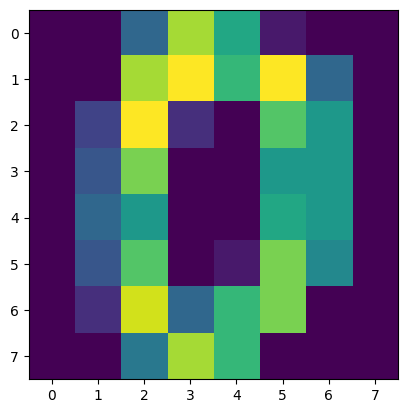

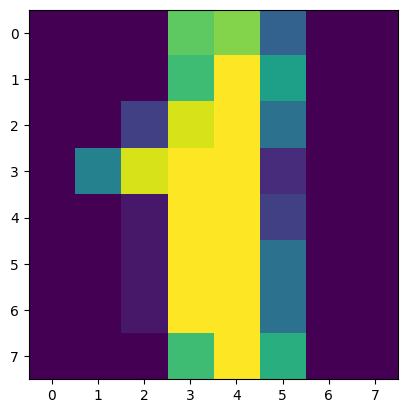

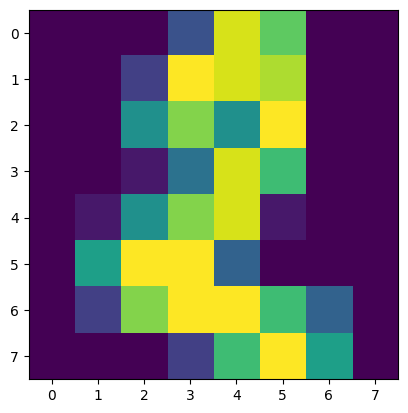

In [12]:
# kilka pierwszych obrazów
for digit in X[:3]:
    plt.imshow(digit.reshape(8,8))
    plt.show()

### ZADANIE 5:
1. Zbuduj model PCA, ale ustaw jego parametr `n_components` np. na 0.90 (dzięki temu model dobierze tyle komponentów, aby zachować 90% oryginalnej wariancji/informacji).
2. Przepuść dane `X` przez ten model używając `fit_transform()`. Zapisz je do zmiennej np. `X_pca`.
3. Sprawdź, ile komponentów ostatecznie zachował algorytm używając parametru instancji: `pca.n_components_`.
4. Wykonaj odwrotność kompresji za pomocą `inverse_transform` na `X_pca` i nadpisz do zmiennej `X_recovered`.
5. Narysuj za pomocą Matplotlib na wykresie oryginalną pierwszą cyfrę `X[0].reshape(8, 8)` oraz jej wersję odtworzoną z kompresji `X_recovered[0].reshape(8, 8)`.

### ZADANIE 6

Wykorzystując przykłady z poprzednich zadań przygotuj:

1. Funkcję `flip_or_not_to_flip(img, prob=0.5)`, która z podanym prawdopodobieństwem wykona lustrzane odbicie przekazanego obrazu i go zwróci.
2. Funkcję `gray_or_not_gray(img, prob=0.5)`, która z podanym prawdopodobieństem przekonwertuje obraz na odcienie szarości.
3. Funkcję `proprocess_images`, która przyjmie listę plików\obrazów do przetworzenia, w której:
   * przekazujemy do funkcji docelowy rozmiar obrazu (do przeskalowania) - sprawdzaj czy przeskalowanie oraz kadrowanie jest konieczne,
   * następnie wywołuj metody z podpunktów 1 oraz 2,
   * obrazy zapisujemy do folderu (ścieżka wskazana w wyłowaniu funkcji `preprocess_images`).


Do załadowania przykładowych obrazów (możesz użyć innych) można wykorzystać poniższy kod (ale uważaj na wywołanie wbudowanej metody `eval()`, może być to czasami bardzo ryzykowne!

```python
img_list = ['rocket', 'astronaut', 'retina', 'grass', 'camera', 'cat', 'coffee']
for img in img_list:
    plt.imshow(eval(f'data.{img}()'))
    plt.show()
```

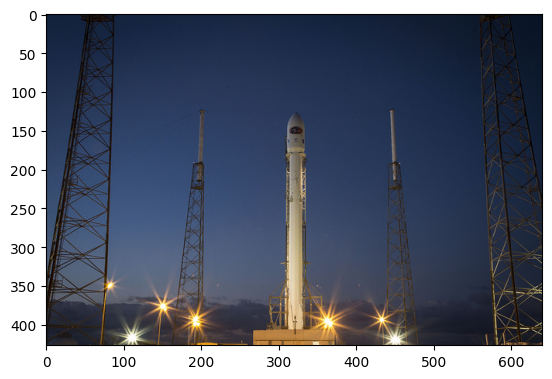

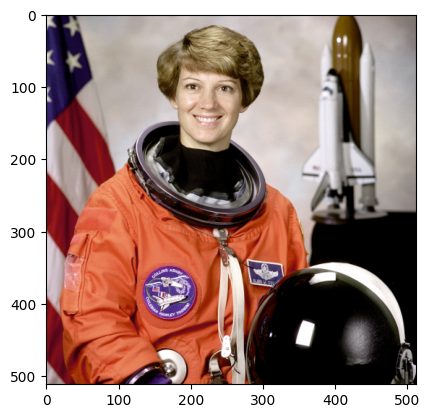

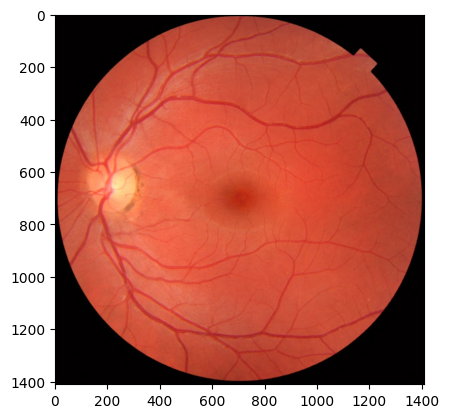

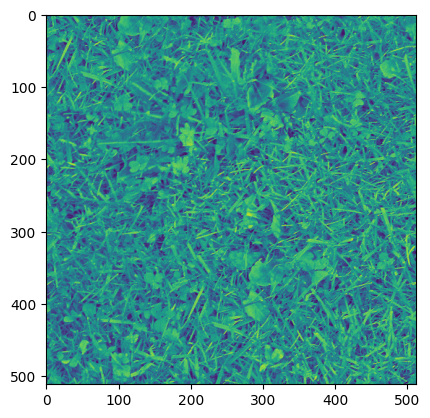

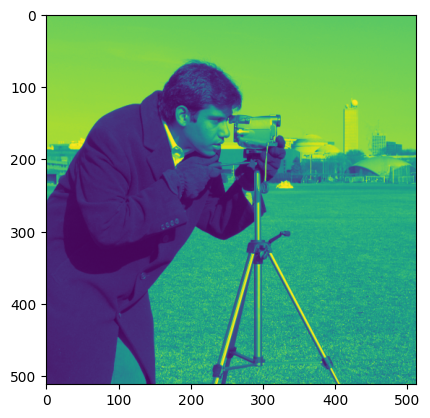

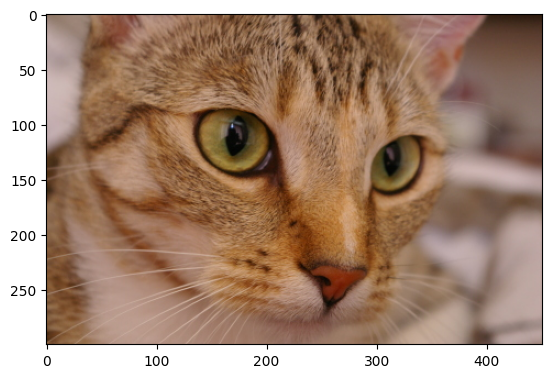

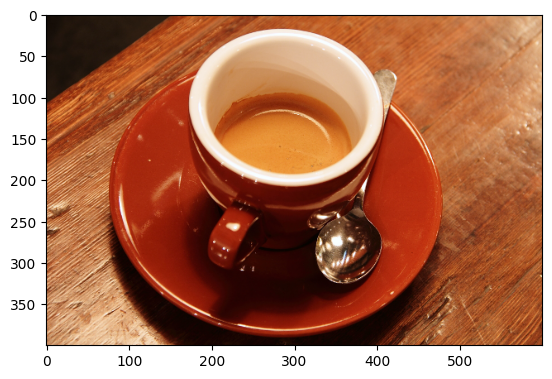